## <center><font color=navy>Engineering Analytics VI</font></center>
### <center>Teoria Moderna de Portfolio</center>

###### Adaptado do material de Ali Habibnia (https://github.com/AliHabibnia/Algorithmic_Trading_with_Python/)

Harry Markowitz introduziu a teoria moderna de portfólio em seu artigo de 1952 intitulado "Portfolio Selection". Ele começa destacando que a seleção de portfólio é um processo de duas etapas; primeiramente, um investidor deve considerar o desempenho futuro dos ativos disponíveis (em termos de risco e retorno) e, posteriormente, pode-se tomar uma decisão sobre como construir o portfólio (ou seja, quanto dinheiro alocar para cada ativo).

Markowitz foca no aspecto da construção do portfólio e deixa a tarefa mais especulativa de prever o desempenho futuro para o leitor. De fato, ao longo do artigo, assume-se que os retornos seguem uma simples distribuição Gaussiana (Normal). Essa suposição é a base sobre a qual toda a teoria moderna de portfólio está fundamentada, mas tem sido alvo de muitas críticas, pois os retornos dos preços das ações demonstraram não seguir uma distribuição normal.

### Baixar os Preços das Criptomoedas

Deixemos as críticas de lado e escrevamos um código em Python para plotar o "Markowitz bullet" e entender melhor a teoria matemática que rendeu a Markowitz o Prêmio Nobel.

Para esta demonstração, escolhemos criptomoedas com as maiores capitalizações de mercado ou volumes de negociação, garantindo um tamanho de amostra adequado. Veja https://coinmarketcap.com/

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
from scipy.optimize import minimize
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
symbols = ['BTC-USD','ETH-USD','XRP-USD','USDT-USD','LTC-USD','BCH-USD','LINK-USD','ADA-USD','BNB-USD', 'USDC-USD', 'HEX-USD', 'LUNA1-USD', 'DOGE-USD', 'MATIC-USD', 'BUSD-USD', 'CRO-USD', 'WBTC-USD', 'BCH-USD', 'TRX-USD', 'FTM-USD', 'XLM-USD'] #
Pr = pd.DataFrame()
for symbol in symbols:
    tmp_close = yf.download(symbol, 
                      start='2020-01-01', 
                      end='2022-03-31', 
                      progress=False)['Close']
    Pr = pd.concat([Pr, tmp_close], axis=1)
Pr.columns=symbols
Pr.tail()

,BTC-USD,ETH-USD,XRP-USD,USDT-USD,LTC-USD,BCH-USD,LINK-USD,ADA-USD,BNB-USD,USDC-USD,...,LUNA1-USD,DOGE-USD,MATIC-USD,BUSD-USD,CRO-USD,WBTC-USD,BCH-USD,TRX-USD,FTM-USD,XLM-USD
Date,,,,,,,,,,,,,,,,,,,,,
2022-03-26,44500.828125,3143.178955,0.832772,1.000361,124.881332,361.893463,15.821914,1.150594,415.919800,0.999892,...,91.387917,0.135868,1.610803,1.001355,0.457645,44509.613281,361.893463,0.066162,1.399129,0.215464
2022-03-27,46820.492188,3291.577637,0.857343,1.000376,129.397476,376.537445,16.849527,1.182148,430.503265,1.000039,...,94.151543,0.144732,1.693481,1.000912,0.485139,46756.945312,376.537445,0.069170,1.430095,0.229787
2022-03-28,47128.003906,3336.634521,0.863304,1.000412,127.938614,368.139282,16.517033,1.170184,430.390869,1.000126,...,97.328468,0.142657,1.660387,0.999873,0.481083,47127.957031,368.139282,0.069081,1.403734,0.230426
2022-03-29,47465.730469,3401.987793,0.858000,1.000450,130.061234,373.529968,16.973129,1.191112,434.505676,0.999996,...,108.988426,0.144470,1.674787,0.998623,0.480683,47491.414062,373.529968,0.069382,1.418792,0.233362
2022-03-30,47062.664062,3385.157959,0.860814,1.000278,131.169342,379.637817,17.209745,1.190385,442.684845,0.999431,...,106.015793,0.143210,1.684619,0.999200,0.474019,47076.789062,379.637817,0.073087,1.409386,0.234819


In [4]:
re = Pr/Pr.shift(1).dropna(how="any")
re.tail()

,BTC-USD,ETH-USD,XRP-USD,USDT-USD,LTC-USD,BCH-USD,LINK-USD,ADA-USD,BNB-USD,USDC-USD,...,LUNA1-USD,DOGE-USD,MATIC-USD,BUSD-USD,CRO-USD,WBTC-USD,BCH-USD,TRX-USD,FTM-USD,XLM-USD
Date,,,,,,,,,,,,,,,,,,,,,
2022-03-26,0.003424,0.011683,0.009223,-0.000045,0.006539,-0.007835,0.015093,0.046890,0.012359,0.000739,...,0.010660,0.036387,0.019578,0.000455,0.004220,0.003983,-0.007835,0.025968,0.036341,0.018262
2022-03-27,0.050813,0.046132,0.029078,0.000015,0.035525,0.039668,0.062927,0.027055,0.034462,0.000147,...,0.029792,0.063200,0.050053,-0.000443,0.058342,0.049258,0.039668,0.044461,0.021891,0.064359
2022-03-28,0.006546,0.013596,0.006929,0.000036,-0.011338,-0.022556,-0.019930,-0.010172,-0.000261,0.000087,...,0.033186,-0.014441,-0.019735,-0.001039,-0.008396,0.007904,-0.022556,-0.001287,-0.018605,0.002777
2022-03-29,0.007141,0.019397,-0.006163,0.000038,0.016455,0.014537,0.027239,0.017726,0.009515,-0.000130,...,0.113150,0.012629,0.008635,-0.001251,-0.000832,0.007683,0.014537,0.004348,0.010670,0.012661
2022-03-30,-0.008528,-0.004959,0.003274,-0.000172,0.008484,0.016219,0.013844,-0.000611,0.018649,-0.000565,...,-0.027654,-0.008760,0.005853,0.000578,-0.013961,-0.008769,0.016219,0.052023,-0.006652,0.006224


<AxesSubplot: xlabel='Date'>

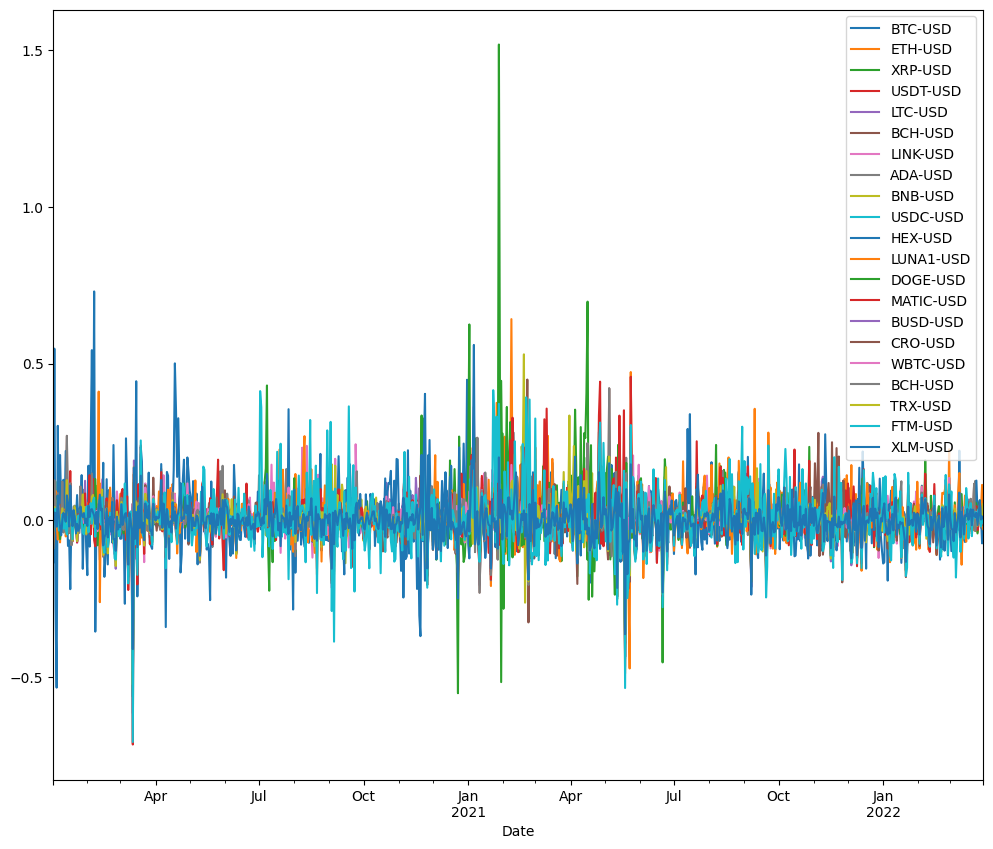

In [5]:
re.plot(figsize=(12,10))

In [6]:
# mean daily returns per coin 
print(re.mean())

# mean daily returns of all cryptos
print('mean of all cryptos=',re.mean().mean())

BTC-USD      2.292277e-03
ETH-USD      3.972492e-03
XRP-USD      1.827735e-03
USDT-USD     5.396133e-07
LTC-USD      1.389985e-03
BCH-USD      7.559840e-04
LINK-USD     2.752145e-03
ADA-USD      4.361100e-03
BNB-USD      4.244517e-03
USDC-USD    -5.665245e-06
HEX-USD      9.264409e-03
LUNA1-USD    7.483325e-03
DOGE-USD     5.195115e-03
MATIC-USD    5.767742e-03
BUSD-USD    -5.074096e-06
CRO-USD      3.218170e-03
WBTC-USD     2.288484e-03
BCH-USD      7.559840e-04
TRX-USD      2.085046e-03
FTM-USD      5.970418e-03
XLM-USD      2.005104e-03
dtype: float64
mean of all cryptos= 0.0031247540612745197


### Minimize o Risco do Portfólio (portfólio de variância mínima)

Nosso objetivo é construir um portfólio com essas criptomoedas com as seguintes restrições:

- O retorno diário esperado deve ser maior que a média de todas elas, ou seja, superior a 0.003.
- Não há venda a descoberto, ou seja, nós apenas compramos criptomoedas, de forma que a soma dos pesos de todas as moedas seja igual a 1.
- Cada moeda pode ter um peso de 0 a 1, ou seja, podemos até construir um portfólio com apenas uma moeda ou excluir algumas moedas.
- Por fim, nosso objetivo é minimizar a variância (ou seja, o risco) do portfólio.

[Documentação do scipy.optimize.minimize](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html#scipy.optimize.minimize)

Também poderíamos resolver a otimização maximizando o Retorno do Portfólio, o Índice de Sharpe ou outras medidas de desempenho do portfólio.

O Índice de Sharpe, desenvolvido pelo Nobel William F. Sharpe, é uma medida para calcular o retorno ajustado pelo risco e tem sido o padrão da indústria para tais cálculos.

O Índice de Sharpe nos permite quantificar a relação entre o retorno médio obtido em excesso da taxa livre de risco por unidade de volatilidade ou risco total. A fórmula para o Índice de Sharpe é apresentada abaixo:

### $Sharpe = \frac{R_P - R_f}{\sigma_p}$


In [7]:
# Função objetivo: minimizar o risco do portfólio
# Essa função calcula a variância (risco) do portfólio com base nos pesos atribuídos a cada ativo.
def objective(weights):
    # Converte a lista de pesos em um array do NumPy para facilitar operações matemáticas
    weights = np.array(weights)
    # Calcula a variância do portfólio utilizando a fórmula:
    # Variância = w^T * Cov * w, onde:
    # - w é o vetor de pesos dos ativos,
    # - Cov é a matriz de covariância dos retornos dos ativos.
    # A operação weights.dot(re.cov()) multiplica o vetor de pesos pela matriz de covariância,
    # e o resultado é multiplicado pelo vetor de pesos transposto (weights.T).
    return weights.dot(re.cov()).dot(weights.T)

# Definição das restrições para a otimização
cons = (
    # Restrição 1 (igualdade): A soma de todos os pesos deve ser igual a 1.
    # Isso garante que 100% do capital seja alocado entre os ativos.
    {"type": "eq", "fun": lambda x: np.sum(x) - 1},
    
    # Restrição 2 (desigualdade): O retorno diário esperado do portfólio deve ser maior que 0.003.
    # Aqui, re.mean() calcula o retorno médio de cada ativo.
    # Multiplicamos cada retorno médio pelo peso correspondente (x) e somamos todos.
    # A restrição exige que essa soma seja, no mínimo, 0.003.
    {"type": "ineq", "fun": lambda x: np.sum(re.mean() * x) - 0.003}
)

# Definição dos limites (bounds) para os pesos de cada ativo:
# Cada ativo pode receber um peso entre 0 e 1, ou seja,
# não podemos alocar um peso negativo (sem venda a descoberto) nem um peso superior a 100% em um único ativo.
bounds = tuple((0, 1) for x in range(re.shape[1]))

# Inicialização dos pesos com uma distribuição uniforme:
# Supondo que temos N ativos, cada um inicia com o peso 1/N, garantindo uma distribuição igualitária do capital.
guess = [1. / re.shape[1] for x in range(re.shape[1])]

# Otimização dos pesos do portfólio para minimizar o risco utilizando o método SLSQP (Sequential Least SQuares Programming):
# Esse método é adequado para problemas de otimização com restrições tanto de igualdade quanto de desigualdade.
optimized_results = minimize(objective, guess, method="SLSQP", bounds=bounds, constraints=cons)

# Exibe os resultados da otimização, que incluem os pesos ótimos para cada ativo no portfólio.
optimized_results

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 0.0005817473937966068
       x: [ 3.903e-04  6.818e-03 ...  9.836e-03  0.000e+00]
     nit: 18
     jac: [ 1.085e-03  1.519e-03 ...  2.362e-03  1.471e-03]
    nfev: 396
    njev: 18

In [8]:
pd.DataFrame(list(zip(symbols, optimized_results.x)), 
                       columns=['Symbol', 'Weight'])

,Symbol,Weight
0,BTC-USD,3.903193e-04
1,ETH-USD,6.817995e-03
2,XRP-USD,4.336809e-19
3,USDT-USD,1.969950e-01
4,LTC-USD,5.434563e-18
5,BCH-USD,4.336809e-19
6,LINK-USD,0.000000e+00
7,ADA-USD,2.305708e-02
8,BNB-USD,2.373836e-02
9,USDC-USD,1.944341e-01


In [9]:
np.sum(optimized_results.x)

1.0000000000000002

Podemos ver que o retorno esperado do Portfolio é:

In [10]:
np.sum(re.mean()*optimized_results.x)

0.0029999999996331303

### Otimização de Portfólio: Simulação de Monte Carlo

Uma abordagem que podemos adotar é verificar uma série de alocações aleatórias e identificar qual delas apresenta o melhor Índice de Sharpe, PR ou menor Variância.

O que faremos é atribuir aleatoriamente um peso para cada ativo do nosso portfólio e, em seguida, calcular o retorno médio diário e o desvio padrão dos retornos. Isso nos permite calcular o Índice de Sharpe para diversas alocações selecionadas de forma aleatória.

O que procuramos é identificar qual alocação aleatória possui o melhor Índice de Sharpe.

**Vale ressaltar que adivinhar e testar não é a forma mais eficiente de otimizar um portfólio — em vez disso, podemos utilizar métodos matemáticos e algoritmos de otimização, como na seção anterior, para determinar o Índice de Sharpe ótimo para um portfólio dado.**

Antes de executarmos milhares de alocações aleatórias, vamos realizar uma única alocação aleatória. Para isso, vamos:

- Definir nossos pesos como um array aleatório do NumPy
- Rebalancear os pesos para que a soma seja igual a 1
- Calcular o retorno esperado do portfólio
- Calcular a volatilidade esperada do portfólio
- Calcular o Índice de Sharpe

Tenha em mente que este portfólio é geralmente destinado a ser um investimento anual, por isso vamos multiplicar o retorno e a covariância por 252 para obter o retorno anualizado e a covariância. Para o mercado de ações dos EUA, o número médio de dias de negociação é de aproximadamente 252 dias.

**As criptomoedas podem ser negociadas 24 horas por dia, 365 dias por ano, incluindo fins de semana e feriados.**

In [11]:
# Gerar pesos aleatórios para cada ativo no portfólio
weights = np.array(np.random.random(re.shape[1]))
print('Pesos Aleatórios:')
print(weights)

# Rebalancear os pesos para que a soma total seja igual a 1 (100% do capital)
print('Rebalanceando os pesos')
weights = weights / np.sum(weights)
print(weights)

# Calcular o retorno esperado do portfólio
# Multiplicamos pelo fator 365 para anualizar o retorno, assumindo que 're.mean()' fornece o retorno diário
print('Retorno Esperado do Portfólio')
exp_ret = np.sum((re.mean() * weights) * 365)
print(exp_ret)

# Calcular a volatilidade esperada do portfólio
# Anualizamos a matriz de covariância multiplicando por 365 e utilizamos a fórmula: sqrt(w^T * Cov * w)
print('Volatilidade Esperada')
exp_vol = np.sqrt(np.dot(weights.T, np.dot(re.cov() * 365, weights)))
print(exp_vol)

# Calcular o Índice de Sharpe, que é a razão entre o retorno esperado e a volatilidade esperada
print('Índice de Sharpe')
SR = exp_ret / exp_vol
print(SR)

Pesos Aleatórios:
[0.68992107 0.39256324 0.71518853 0.36059138 0.94836853 0.97563336
 0.85213925 0.66924601 0.15266065 0.63994799 0.68191465 0.29955334
 0.33243523 0.82844114 0.15967782 0.00576763 0.67625703 0.1153173
 0.66392403 0.79696173 0.88097495]
Rebalanceando os pesos
[0.05828274 0.03316272 0.06041727 0.03046182 0.08011571 0.08241897
 0.07198651 0.05653617 0.01289638 0.05406115 0.05760638 0.02530549
 0.02808327 0.06998456 0.01348917 0.00048723 0.05712844 0.00974171
 0.05608658 0.06732526 0.07442248]
Retorno Esperado do Portfólio
1.1420468547828504
Volatilidade Esperada
0.8658019306320328
Índice de Sharpe
1.3190624949856136


In [19]:
# Número de portfólios a serem simulados
num_ports = 1000

# Cria uma matriz para armazenar os pesos de cada portfólio.
# Cada linha representará um portfólio e cada coluna, um ativo.
all_weights = np.zeros((num_ports, len(re.columns)))

# Arrays para armazenar o retorno esperado, a volatilidade esperada e o Índice de Sharpe de cada portfólio
ret_arr = np.zeros(num_ports)
vol_arr = np.zeros(num_ports)
sharpe_arr = np.zeros(num_ports)

# Loop para simular "num_ports" portfólios aleatórios
for ind in range(num_ports):
    # Gerar pesos aleatórios para os ativos do portfólio
    weights = np.array(np.random.random(re.shape[1]))
    
    # Rebalancear os pesos para que a soma total seja igual a 1 (100% do capital)
    weights = weights / np.sum(weights)
    
    # Salvar os pesos gerados para este portfólio
    all_weights[ind, :] = weights

    # Calcular o retorno esperado do portfólio (anualizado)
    # re.mean() fornece o retorno diário médio de cada ativo, multiplicamos por 365 para anualizar
    ret_arr[ind] = np.sum((re.mean() * 365 * weights))

    # Calcular a volatilidade esperada do portfólio (anualizada)
    # Utilizamos a matriz de covariância dos retornos diários, multiplicada por 365, e aplicamos a fórmula: sqrt(w^T * Cov * w)
    vol_arr[ind] = np.sqrt(np.dot(weights.T, np.dot(re.cov() * 365, weights)))

    # Calcular o Índice de Sharpe para o portfólio, que é a razão entre o retorno esperado e a volatilidade
    sharpe_arr[ind] = ret_arr[ind] / vol_arr[ind]

In [20]:
sharpe_arr.max()

1.7702236742232886

In [21]:
sharpe_arr.argmax()

53

In [22]:
all_weights[sharpe_arr.argmax(),:]

array([0.09025649, 0.0398396 , 0.02452313, 0.09404868, 0.02946805,
       0.00671742, 0.03487397, 0.0030592 , 0.0732354 , 0.04791092,
       0.09239885, 0.10441138, 0.03190725, 0.00632582, 0.00954416,
       0.03703358, 0.09798776, 0.02282825, 0.0073996 , 0.0988485 ,
       0.04738197])

Text(0, 0.5, 'Return')

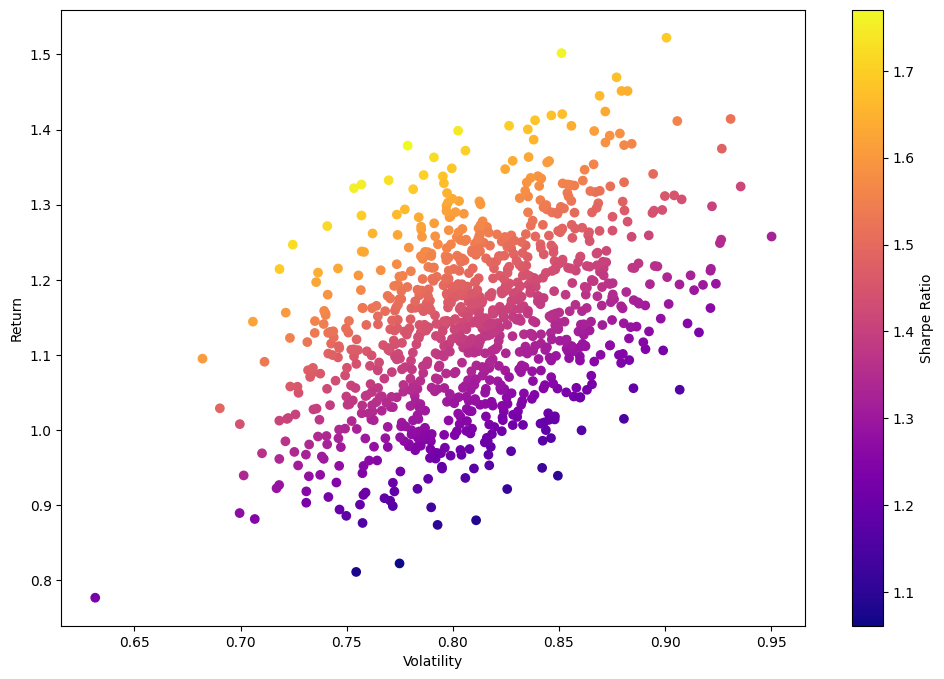

In [23]:
# visualzando os dados
plt.figure(figsize=(12,8))
plt.scatter(vol_arr,ret_arr,c=sharpe_arr,cmap='plasma')
plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Volatility')
plt.ylabel('Return')

Podemos colocar o ponto vermelho na localização de Sharpe máximo.

In [24]:
max_sr_ret = ret_arr[sharpe_arr.argmax()]
max_sr_vol = vol_arr[sharpe_arr.argmax()]

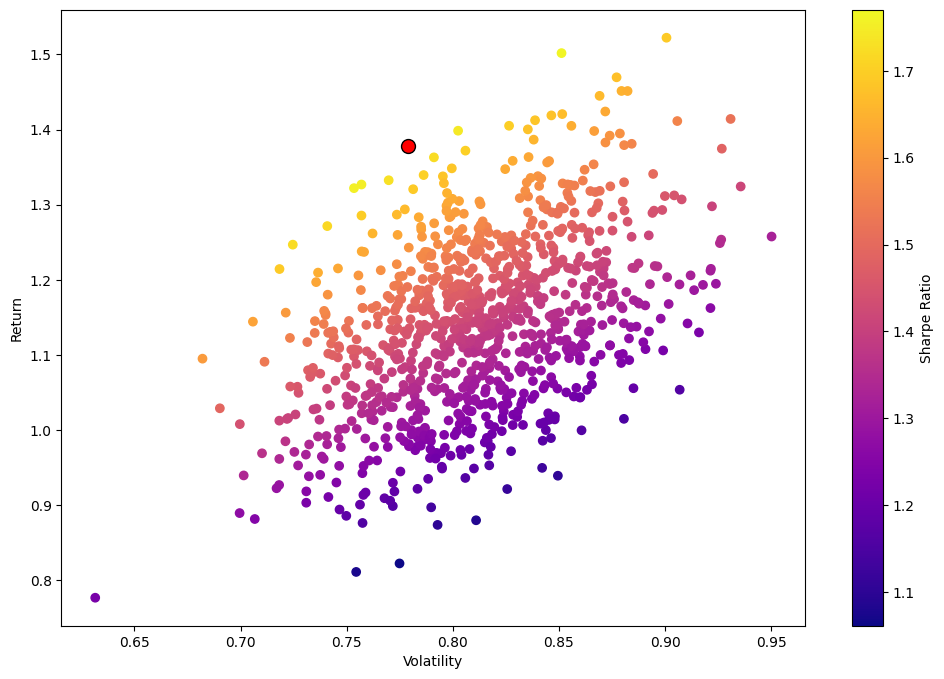

In [25]:
plt.figure(figsize=(12,8))
plt.scatter(vol_arr,ret_arr,c=sharpe_arr,cmap='plasma')
plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Volatility')
plt.ylabel('Return')

# add a red dot for max_sr_vol & max_sr_ret
plt.scatter(max_sr_vol, max_sr_ret, c='red', s=100, edgecolors='black')

## Agora vamos entender na teoria!

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import scipy.optimize as sco

In [10]:
# =============================================================================
# Parâmetros de Configuração
# =============================================================================
# Define se a Capital Market Line (CML) deve ser calculada e plotada (True/False)
calcular_CML = True

# Define a taxa livre de risco (ex: 0 para simplificação ou 0.02 para 2%)
taxa_livre_risco = 0.045

In [11]:
# =============================================================================
# 1. Baixar dados do Yahoo Finance
# =============================================================================
# Lista de ativos para análise
acoes = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']

# Baixa os preços ajustados de fechamento dos ativos no período especificado.
# Usamos a coluna 'Adj Close' para considerar ajustes de splits e dividendos.
dados = yf.download(acoes, start='2018-01-01', end='2023-01-01').droplevel(level=1, axis=1)['Close']

# Calcula os retornos diários percentuais e remove a primeira linha que contém NaN.
retornos = dados.pct_change().dropna()

# =============================================================================
# 2. Calcular Retornos Anualizados e Matriz de Covariância
# =============================================================================
# Calcula o retorno médio diário e anualiza multiplicando por 252 (dias de negociação no ano).
retorno_medio = retornos.mean() * 252

# Calcula a matriz de covariância dos retornos diários e anualiza multiplicando por 252.
matriz_cov = retornos.cov() * 252

[*********************100%***********************]  5 of 5 completed


In [12]:
# =============================================================================
# 3. Definir Funções Auxiliares para Cálculos do Portfólio
# =============================================================================

def variancia_portfolio(pesos, matriz_cov):
    """
    Calcula a variância do portfólio.
    
    Parâmetros:
      pesos (array): Vetor com os pesos dos ativos no portfólio.
      matriz_cov (DataFrame ou array): Matriz de covariância anualizada dos retornos dos ativos.
    
    Retorna:
      Variância do portfólio (float).
    """
    return np.dot(pesos.T, np.dot(matriz_cov, pesos))

def volatilidade_portfolio(pesos, matriz_cov):
    """
    Calcula a volatilidade do portfólio (desvio padrão) a partir da variância.
    
    Parâmetros:
      pesos (array): Vetor com os pesos dos ativos.
      matriz_cov (DataFrame ou array): Matriz de covariância.
      
    Retorna:
      Volatilidade do portfólio (float).
    """
    return np.sqrt(variancia_portfolio(pesos, matriz_cov))

def otimizar_portfolio_para_retorno_alvo(retorno_alvo, retorno_medio, matriz_cov):
    """
    Otimiza os pesos do portfólio para um dado retorno alvo minimizando a variância.
    
    Restrições:
      - A soma dos pesos deve ser igual a 1.
      - O retorno esperado do portfólio deve ser igual ao retorno_alvo.
      - Cada peso deve estar entre 0 e 1 (não permite vendas a descoberto).
    
    Parâmetros:
      retorno_alvo (float): Retorno esperado desejado para o portfólio.
      retorno_medio (Series ou array): Retorno médio anualizado de cada ativo.
      matriz_cov (DataFrame ou array): Matriz de covariância anualizada dos retornos.
      
    Retorna:
      Vetor de pesos otimizados (array) ou None se a otimização não for bem-sucedida.
    """
    num_ativos = len(retorno_medio)
    args = (matriz_cov,)
    
    # Define as restrições:
    # 1. A soma dos pesos deve ser igual a 1.
    # 2. O retorno do portfólio (produto escalar entre os pesos e o retorno médio) deve ser igual ao retorno_alvo.
    restricoes = (
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
        {'type': 'eq', 'fun': lambda x: np.dot(x, retorno_medio) - retorno_alvo}
    )
    
    # Define os limites para cada peso: entre 0 e 1.
    limites = tuple((0, 1) for _ in range(num_ativos))
    
    # Inicializa com pesos iguais para todos os ativos.
    pesos_iniciais = np.ones(num_ativos) / num_ativos
    
    # Realiza a otimização usando o método SLSQP (Sequential Least Squares Programming).
    resultado = sco.minimize(variancia_portfolio, pesos_iniciais, args=args,
                             method='SLSQP', bounds=limites, constraints=restricoes)
    
    # Retorna os pesos otimizados se a otimização for bem-sucedida.
    return resultado.x if resultado.success else None

In [13]:
# =============================================================================
# 4. Gerar a Fronteira Eficiente Otimizada
# =============================================================================
# Inicializa listas para armazenar os resultados da otimização:
volatilidade_fronteira = []  # Volatilidade (risco) dos portfólios otimizados
retorno_fronteira = []       # Retorno dos portfólios otimizados
pesos_fronteira = []         # Pesos dos ativos nos portfólios da fronteira

# Define um intervalo de retornos alvo, variando do menor ao maior retorno médio anualizado.
retornos_alvo = np.linspace(retorno_medio.min(), retorno_medio.max(), 50)

# Para cada retorno alvo, otimiza o portfólio e armazena os resultados
for alvo in retornos_alvo:
    pesos_otimizados = otimizar_portfolio_para_retorno_alvo(alvo, retorno_medio, matriz_cov)
    if pesos_otimizados is not None:
        # Calcula o retorno efetivo do portfólio utilizando os pesos otimizados
        ret = np.dot(pesos_otimizados, retorno_medio)
        # Calcula a volatilidade (risco) do portfólio otimizado
        vol = volatilidade_portfolio(pesos_otimizados, matriz_cov)
        retorno_fronteira.append(ret)
        volatilidade_fronteira.append(vol)
        pesos_fronteira.append(pesos_otimizados)

# Converte as listas para arrays para facilitar o uso na plotagem
volatilidade_fronteira = np.array(volatilidade_fronteira)
retorno_fronteira = np.array(retorno_fronteira)

In [14]:
# =============================================================================
# 5. Simulação de Portfólios Aleatórios (Opcional para Comparação)
# =============================================================================
num_portfolios = 50000  # Define o número de portfólios aleatórios a serem simulados

# Cria uma matriz para armazenar os resultados:
# Linha 0: volatilidade, Linha 1: retorno, Linha 2: Índice de Sharpe
resultados = np.zeros((3, num_portfolios))
registro_pesos = []  # Lista para armazenar os pesos de cada portfólio simulado

# Loop para gerar cada portfólio aleatório
for i in range(num_portfolios):
    # Gera pesos aleatórios para cada ativo
    pesos = np.random.random(len(acoes))
    # Normaliza os pesos para que a soma seja igual a 1
    pesos /= np.sum(pesos)
    registro_pesos.append(pesos)
    
    # Calcula o retorno do portfólio utilizando os pesos gerados
    ret_port = np.dot(pesos, retorno_medio)
    # Calcula a volatilidade do portfólio utilizando a matriz de covariância
    vol_port = np.sqrt(np.dot(pesos.T, np.dot(matriz_cov, pesos)))
    
    # Armazena os resultados na matriz
    resultados[0, i] = vol_port
    resultados[1, i] = ret_port
    # Calcula o Índice de Sharpe considerando a taxa livre de risco
    resultados[2, i] = (ret_port - taxa_livre_risco) / vol_port

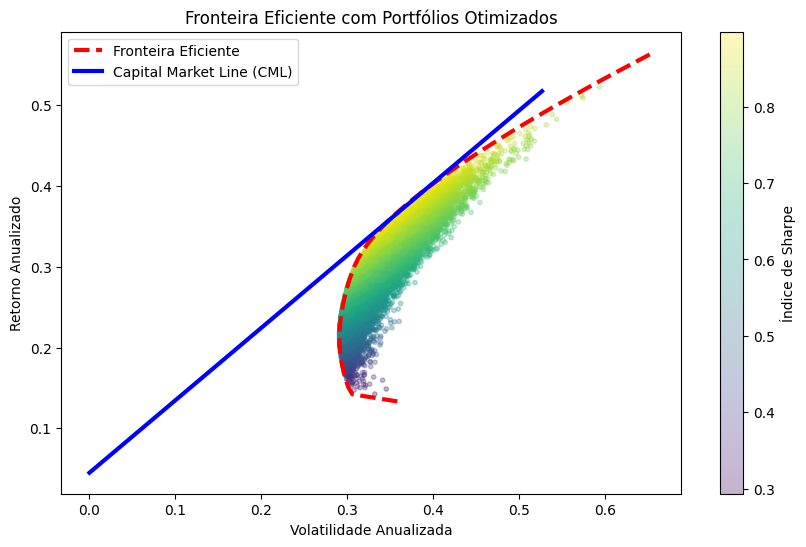

In [15]:
# =============================================================================
# 6. Plotagem dos Resultados e, opcionalmente, da Capital Market Line (CML)
# =============================================================================
plt.figure(figsize=(10, 6))

# Plota os portfólios aleatórios em um gráfico de dispersão (scatter plot)
# A cor de cada ponto representa o Índice de Sharpe
plt.scatter(resultados[0, :], resultados[1, :], c=resultados[2, :],
            cmap='viridis', marker='o', s=10, alpha=0.3)

# Plota a linha da fronteira eficiente otimizada, utilizando os valores de volatilidade e retorno calculados
plt.plot(volatilidade_fronteira, retorno_fronteira, 'r--', linewidth=3, label='Fronteira Eficiente')

# Se o parâmetro calcular_CML for True, calcula e plota a Capital Market Line
if calcular_CML:
    # Identifica o portfólio tangente (aquele com o maior Índice de Sharpe)
    # (retorno - taxa_livre_risco)/volatilidade para cada portfólio simulado
    sharpe_simulacao = (resultados[1, :] - taxa_livre_risco) / resultados[0, :]
    indice_tangent = np.argmax(sharpe_simulacao)
    retorno_tangent = resultados[1, indice_tangent]
    vol_tangent = resultados[0, indice_tangent]
    sharpe_tangent = sharpe_simulacao[indice_tangent]
    
    # Define um intervalo de volatilidade para plotar a CML, começando do 0 até um valor maior que a volatilidade do portfólio tangente
    vol_range = np.linspace(0, vol_tangent * 1.5, 100)
    # A equação da CML: retorno = taxa_livre_risco + (Índice de Sharpe do portfólio tangente) * volatilidade
    retorno_CML = taxa_livre_risco + sharpe_tangent * vol_range
    
    # Plota a CML no mesmo gráfico
    plt.plot(vol_range, retorno_CML, 'b-', linewidth=3, label='Capital Market Line (CML)')

# Adiciona título e rótulos aos eixos
plt.title('Fronteira Eficiente com Portfólios Otimizados')
plt.xlabel('Volatilidade Anualizada')
plt.ylabel('Retorno Anualizado')

# Adiciona uma barra de cores para representar o Índice de Sharpe
plt.colorbar(label='Índice de Sharpe')

# Exibe a legenda e mostra o gráfico
plt.legend()
plt.show()